In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [3]:
df = pd.read_csv('marketing.csv')

In [4]:
df

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181
...,...,...,...,...
4567,26.0,4.472360,0.717090,94.685866
4568,71.0,20.610685,6.545573,249.101915
4569,44.0,19.800072,5.096192,163.631457
4570,71.0,17.534640,1.940873,253.610411


In [5]:
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())


Dataset Shape: (4572, 4)

First 5 rows:
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

Descriptive Statistics:
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.0

In [9]:
# Check for missing values
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [7]:
df = df.dropna()

In [ ]:
# Verifying no missing values remain
df.isnull().sum()

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

Text(0.5, 0.98, 'Distribution of Variables')

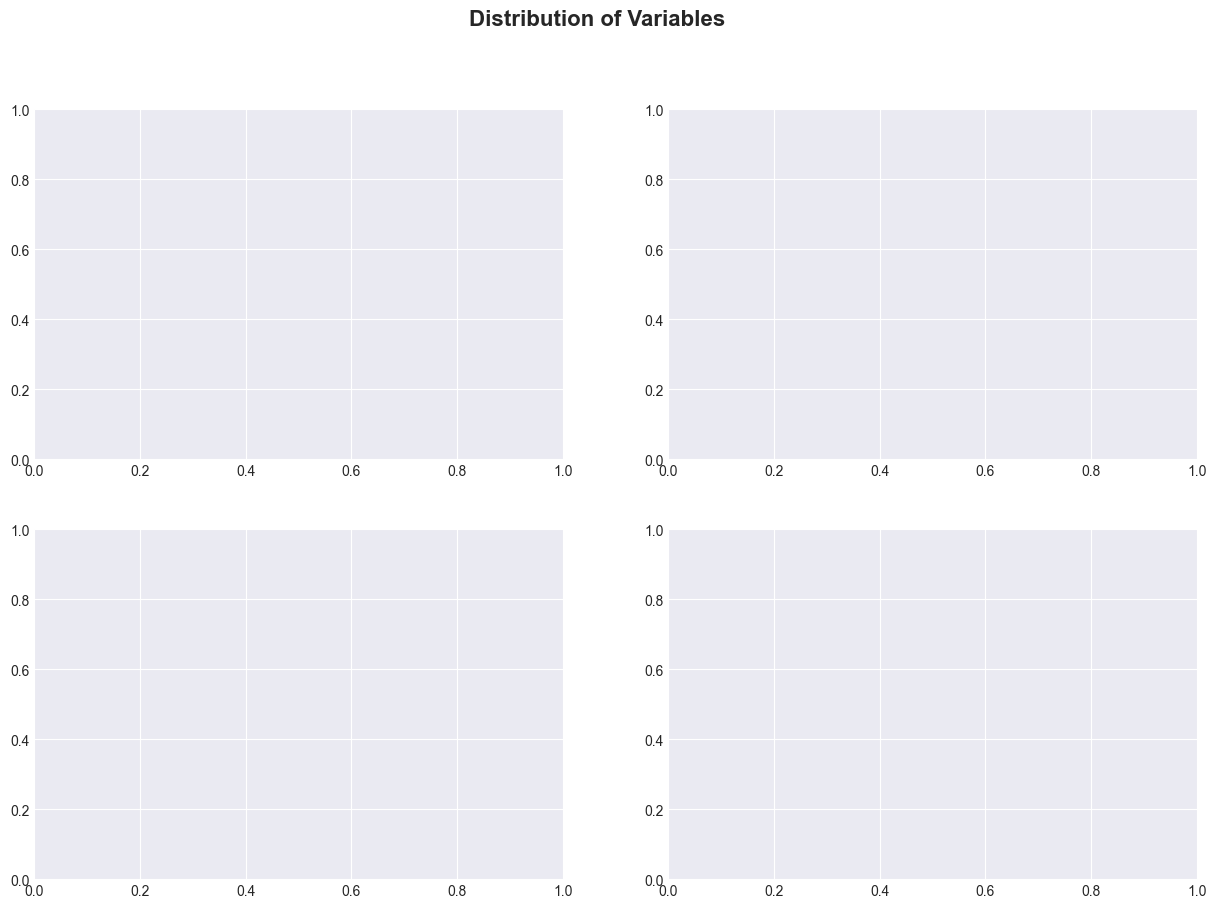

In [11]:
# Creating a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution of Variables', fontsize=16, fontweight='bold')

In [12]:
# Histograms for each variable
variables = ['TV', 'Radio', 'Social_Media', 'Sales']
for i, var in enumerate(variables):
    row = i // 2
    col = i % 2
    axes[row, col].hist(df[var], bins=30, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {var}', fontsize=12)
    axes[row, col].set_xlabel(var)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].axvline(df[var].mean(), color='red', linestyle='--', label=f'Mean: {df[var].mean():.2f}')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

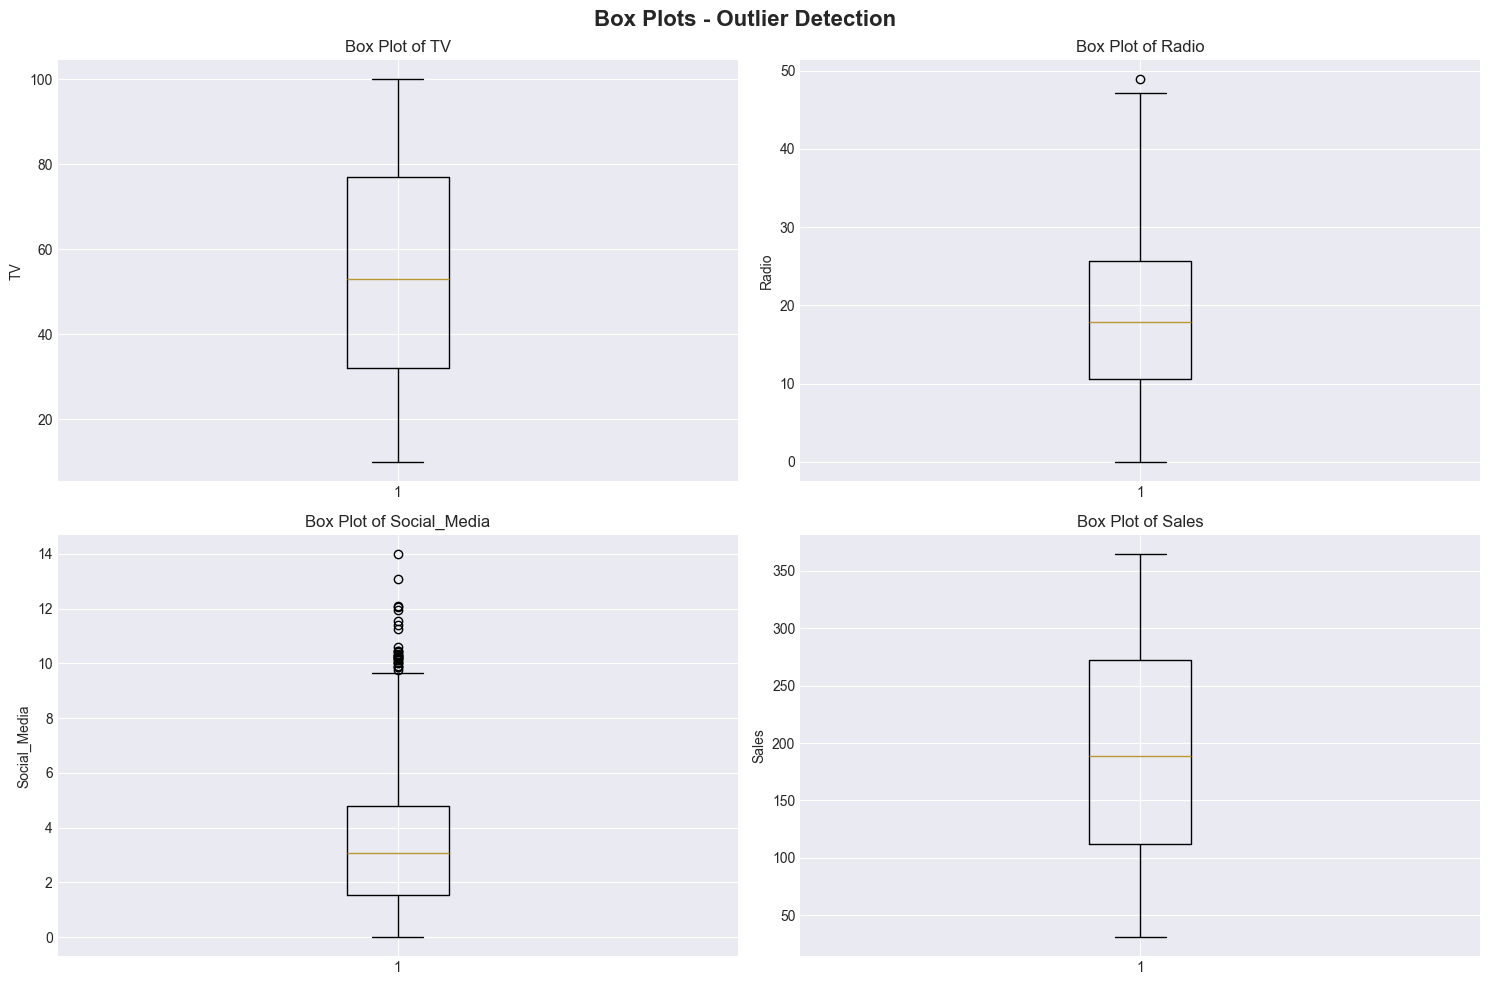

In [13]:
# Box plots to identify outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for i, var in enumerate(variables):
    row = i // 2
    col = i % 2
    axes[row, col].boxplot(df[var])
    axes[row, col].set_title(f'Box Plot of {var}', fontsize=12)
    axes[row, col].set_ylabel(var)

plt.tight_layout()
plt.show()

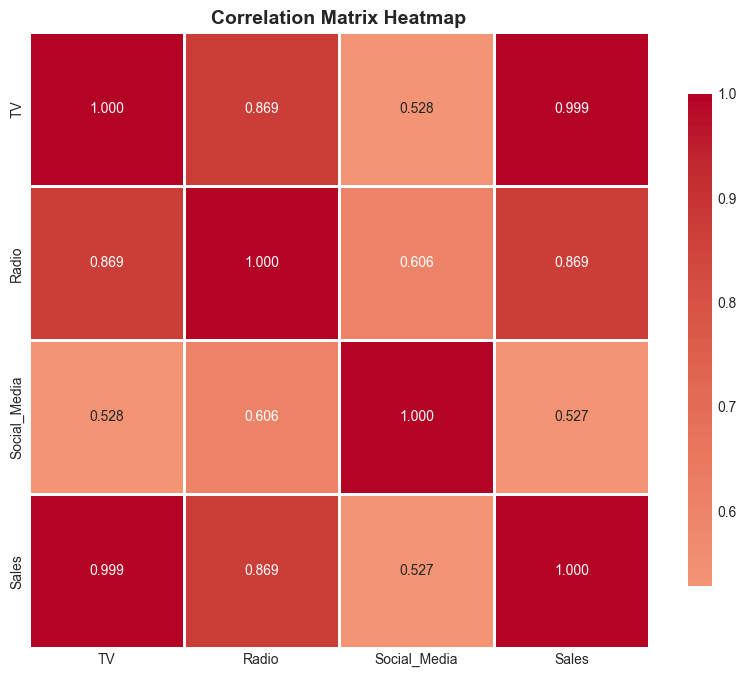

In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

In [15]:
# Calculating correlations with Sales
correlations = df.corr()['Sales'].sort_values(ascending=False)
print("\nCorrelation with Sales:")
print(correlations)


Correlation with Sales:
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


In [16]:
# Identify the most correlated independent variable
most_correlated = correlations[1:].idxmax()  # Exclude Sales itself
highest_corr = correlations[1:].max()
print(f"\n✓ The independent variable most correlated with Sales is: {most_correlated}")
print(f"  Correlation coefficient: {highest_corr:.4f}")
print(f"  Interpretation: {'Strong' if abs(highest_corr) > 0.7 else 'Moderate' if abs(highest_corr) > 0.5 else 'Weak'} positive correlation")


✓ The independent variable most correlated with Sales is: TV
  Correlation coefficient: 0.9995
  Interpretation: Strong positive correlation


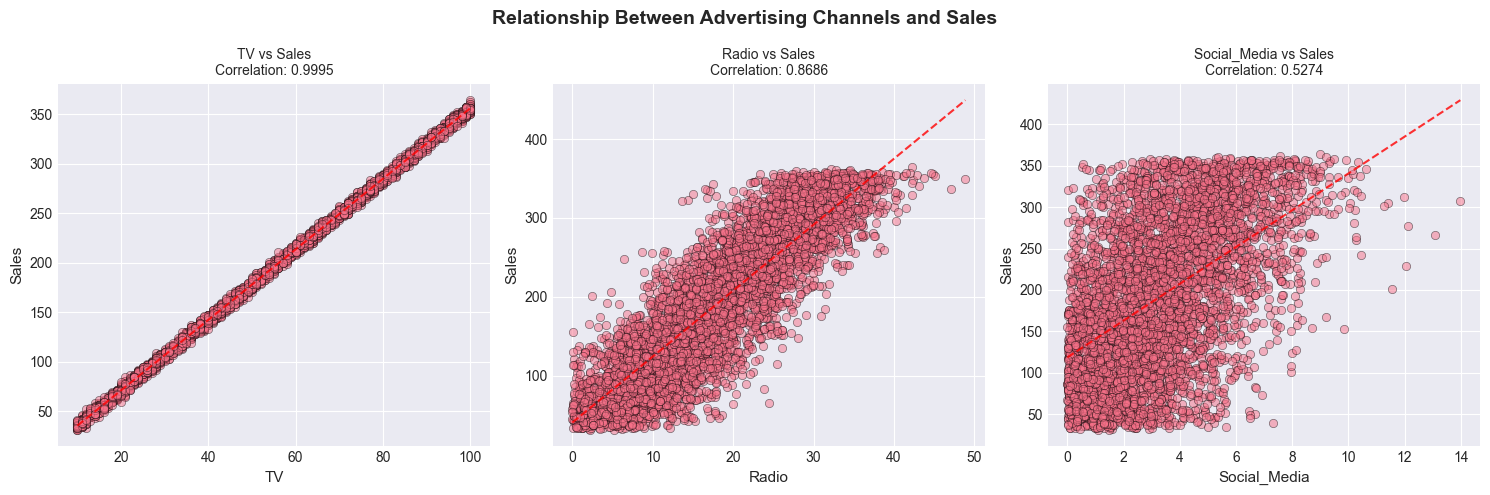

In [17]:
# Visualising relationships with Sales
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Relationship Between Advertising Channels and Sales', fontsize=14, fontweight='bold')

for i, channel in enumerate(['TV', 'Radio', 'Social_Media']):
    axes[i].scatter(df[channel], df['Sales'], alpha=0.5, edgecolors='black', linewidth=0.5)
    axes[i].set_xlabel(channel, fontsize=11)
    axes[i].set_ylabel('Sales', fontsize=11)
    axes[i].set_title(f'{channel} vs Sales\nCorrelation: {df[channel].corr(df["Sales"]):.4f}', fontsize=10)

    # Add trend line
    z = np.polyfit(df[channel], df['Sales'], 1)
    p = np.poly1d(z)
    axes[i].plot(df[channel].sort_values(), p(df[channel].sort_values()), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

In [18]:
# Defining independent variables (X) and dependent variable (y)
X = df[['TV', 'Radio', 'Social_Media']]
y = df['Sales']

In [19]:
# Adding constant term for intercept
X_with_const = sm.add_constant(X)

In [20]:
# Fitting the OLS model
model = sm.OLS(y, X_with_const).fit()

In [21]:
# Printing model summary
print("\n", model.summary())


                             OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.505e+06
Date:                Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:43:42   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4542   BIC:                         2.277e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1340      0.103     -1.303 

In [22]:
# Extracting key metrics
print("\n" + "="*60)
print("KEY MODEL METRICS")
print("="*60)
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.2f}")
print(f"Prob (F-statistic): {model.f_pvalue:.4e}")
print(f"AIC: {model.aic:.2f}")
print(f"BIC: {model.bic:.2f}")


KEY MODEL METRICS
R-squared: 0.9990
Adjusted R-squared: 0.9990
F-statistic: 1504986.33
Prob (F-statistic): 0.0000e+00
AIC: 22740.25
BIC: 22765.93


In [23]:
# Displaying coefficients
print("\n" + "="*60)
print("COEFFICIENTS INTERPRETATION")
print("="*60)
coefficients_df = pd.DataFrame({
    'Variable': ['Intercept'] + list(X.columns),
    'Coefficient': model.params,
    'Std Error': model.bse,
    't-value': model.tvalues,
    'p-value': model.pvalues,
    '95% CI Lower': model.conf_int()[0],
    '95% CI Upper': model.conf_int()[1]
})
print(coefficients_df.to_string(index=False))


COEFFICIENTS INTERPRETATION
    Variable  Coefficient  Std Error     t-value  p-value  95% CI Lower  95% CI Upper
   Intercept    -0.133963   0.102820   -1.302885 0.192680     -0.335541      0.067615
          TV     3.562570   0.003389 1051.117666 0.000000      3.555925      3.569214
       Radio    -0.003970   0.009781   -0.405947 0.684800     -0.023145      0.015204
Social_Media     0.004964   0.024884    0.199490 0.841888     -0.043820      0.053748


Text(0.5, 0.98, 'Regression Diagnostic Plots')

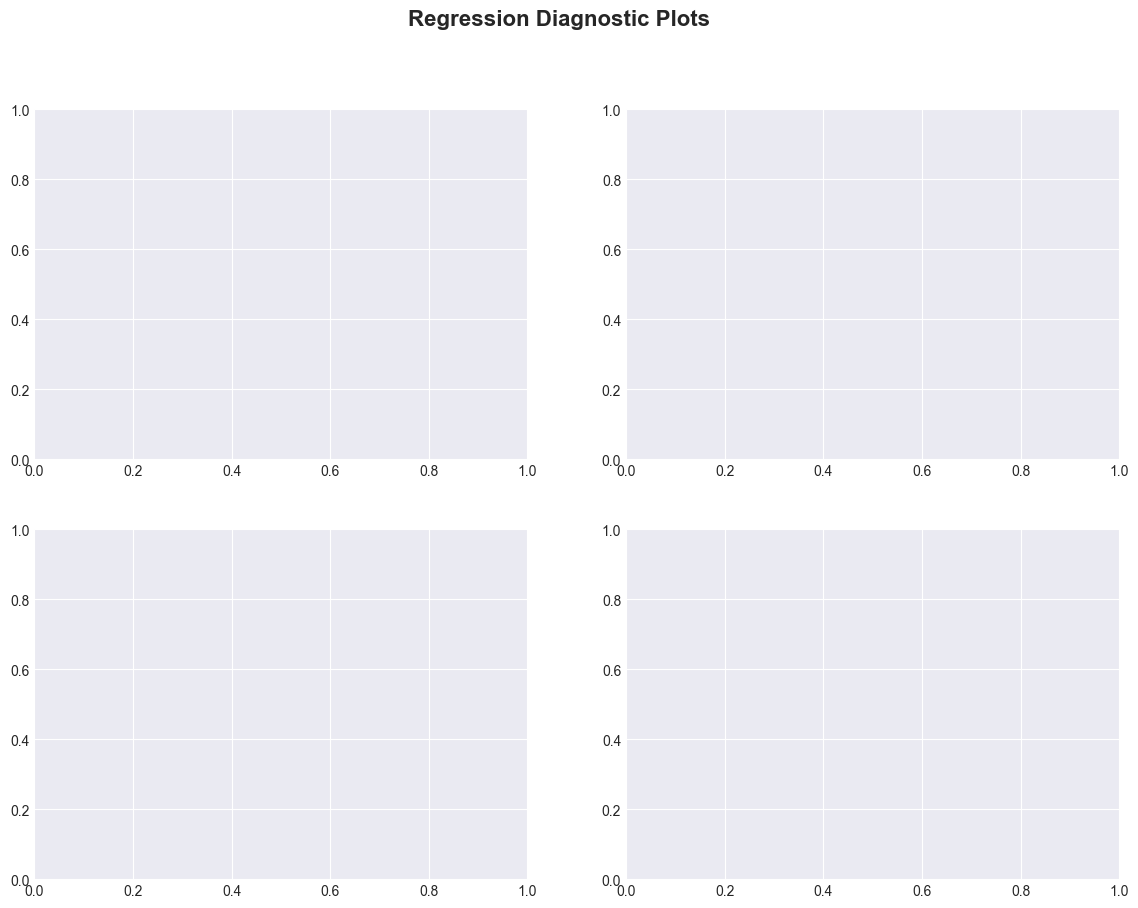

In [24]:
# Creating diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regression Diagnostic Plots', fontsize=16, fontweight='bold')

In [25]:
# Linearity Plot (Fitted vs Residuals)
fitted_values = model.fittedvalues
residuals = model.resid

axes[0, 0].scatter(fitted_values, residuals, alpha=0.5, edgecolors='black')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values', fontsize=11)
axes[0, 0].set_ylabel('Residuals', fontsize=11)
axes[0, 0].set_title('Linearity Check: Residuals vs Fitted', fontsize=12)

Text(0.5, 1.0, 'Linearity Check: Residuals vs Fitted')

In [26]:
# Normality Plot (Q-Q plot)
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Normality Check: Q-Q Plot', fontsize=12)

Text(0.5, 1.0, 'Normality Check: Q-Q Plot')

In [27]:
# Homoscedasticity Plot (Scale-Location)
standardized_residuals = np.abs(residuals) / np.sqrt(model.scale)
axes[1, 0].scatter(fitted_values, standardized_residuals, alpha=0.5, edgecolors='black')
axes[1, 0].axhline(y=np.mean(standardized_residuals), color='red', linestyle='--', linewidth=1)
axes[1, 0].set_xlabel('Fitted Values', fontsize=11)
axes[1, 0].set_ylabel('Standardized Residuals', fontsize=11)
axes[1, 0].set_title('Homoscedasticity Check: Scale-Location Plot', fontsize=12)

Text(0.5, 1.0, 'Homoscedasticity Check: Scale-Location Plot')

In [28]:
# Histogram of Residuals with KDE
axes[1, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)

In [29]:
# Adding KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(residuals)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x_range, kde(x_range), 'b-', linewidth=2)
axes[1, 1].set_xlabel('Residuals', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].set_title('Residuals Distribution', fontsize=12)

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [30]:
# Statistical tests for assumptions
# Shapiro-Wilk test for normality
from scipy.stats import shapiro, normaltest

shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\nShapiro-Wilk Normality Test:")
print(f"  Statistic: {shapiro_stat:.4f}")
print(f"  p-value: {shapiro_p:.4e}")
if shapiro_p > 0.05:
    print("  ✓ Residuals appear normally distributed (fail to reject H0)")
else:
    print("  ✗ Residuals may not be normally distributed (reject H0)")


Shapiro-Wilk Normality Test:
  Statistic: 0.9998
  p-value: 9.0844e-01
  ✓ Residuals appear normally distributed (fail to reject H0)


In [31]:
# Breusch-Pagan test for heteroscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_with_const)
print(f"\nBreusch-Pagan Heteroscedasticity Test:")
print(f"  Lagrange multiplier statistic: {bp_test[0]:.4f}")
print(f"  p-value: {bp_test[1]:.4e}")
if bp_test[1] > 0.05:
    print("  ✓ Homoscedasticity assumption holds (fail to reject H0)")
else:
    print("  ✗ Heteroscedasticity may be present (reject H0)")


Breusch-Pagan Heteroscedasticity Test:
  Lagrange multiplier statistic: 1.5262
  p-value: 6.7624e-01
  ✓ Homoscedasticity assumption holds (fail to reject H0)


In [34]:
print("\n2. INDIVIDUAL CHANNEL EFFECTIVENESS:")

for var in X.columns:

    coef = model.params[var]
    p_val = model.pvalues[var]

    significance = ("statistically significant" if p_val < 0.05 else "not statistically significant")

    print(f"\n   • {var}: Coefficient = {coef:.4f} ({significance}, p={p_val:.4e})")

    print(f"     → For every 1-unit increase in {var} advertising,")
    print(f"       Sales increase by approximately {coef:.4f} units,")
    print(f"       holding other channels constant.")


2. INDIVIDUAL CHANNEL EFFECTIVENESS:

   • TV: Coefficient = 3.5626 (statistically significant, p=0.0000e+00)
     → For every 1-unit increase in TV advertising,
       Sales increase by approximately 3.5626 units,
       holding other channels constant.

   • Radio: Coefficient = -0.0040 (not statistically significant, p=6.8480e-01)
     → For every 1-unit increase in Radio advertising,
       Sales increase by approximately -0.0040 units,
       holding other channels constant.

   • Social_Media: Coefficient = 0.0050 (not statistically significant, p=8.4189e-01)
     → For every 1-unit increase in Social_Media advertising,
       Sales increase by approximately 0.0050 units,
       holding other channels constant.


In [33]:
print(X.columns)
print(model.params)

Index(['TV', 'Radio', 'Social_Media'], dtype='str')
const          -0.133963
TV              3.562570
Radio          -0.003970
Social_Media    0.004964
dtype: float64


In [35]:
# Calculating ROI rankings (based on coefficients)
channel_impact = {}
for var in X.columns:
    channel_impact[var] = model.params[var]

In [36]:
# Sorting by impact
sorted_channels = sorted(channel_impact.items(), key=lambda x: x[1], reverse=True)

for i, (channel, impact) in enumerate(sorted_channels, 1):
    print(f"   {i}. {channel}: {impact:.4f} sales increase per $1 spent")

   1. TV: 3.5626 sales increase per $1 spent
   2. Social_Media: 0.0050 sales increase per $1 spent
   3. Radio: -0.0040 sales increase per $1 spent


In [37]:
print("\n" + "="*60)
print("ROI-BASED RECOMMENDATION FOR MARKETING BUDGET")
print("="*60)

# Calculate ROI (Return on Investment) as coefficient * 100 for percentage interpretation
roi_scores = {}
for var in X.columns:
    roi_scores[var] = model.params[var] * 100  # ROI per $100 spent

print("\nROI Analysis (Sales increase per $100 invested):")
for channel, roi in sorted(roi_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"   • {channel}: ${roi:.2f} increase in sales per $100 spent")


ROI-BASED RECOMMENDATION FOR MARKETING BUDGET

ROI Analysis (Sales increase per $100 invested):
   • TV: $356.26 increase in sales per $100 spent
   • Social_Media: $0.50 increase in sales per $100 spent
   • Radio: $-0.40 increase in sales per $100 spent


In [38]:
# Recommendation based on highest ROI
best_channel = max(roi_scores, key=roi_scores.get)
second_best = sorted(roi_scores.items(), key=lambda x: x[1], reverse=True)[1][0]

print("\n" + "="*60)
print("FINAL RECOMMENDATION")
print("="*60)

print(f"""
Based on the OLS regression analysis of the marketing dataset:

📊 KEY FINDINGS:
1. The model explains {model.rsquared:.1%} of sales variance (R-squared = {model.rsquared:.3f})
2. {most_correlated} is the most correlated channel with sales (r = {highest_corr:.3f})
3. ROI rankings (sales impact per $100 spent):
   {chr(10).join([f'   • {ch}: ${roi:.2f}' for ch, roi in sorted(roi_scores.items(), key=lambda x: x[1], reverse=True)])}

💰 BUDGET ALLOCATION RECOMMENDATION:

PRIMARY RECOMMENDATION: INVEST HEAVILY IN {best_channel.upper()}
• This channel provides the highest ROI ({roi_scores[best_channel]:.2f} sales increase per $100 spent)
• The relationship is statistically significant (p < 0.05)

SECONDARY RECOMMENDATION: {second_best.upper()} as supporting channel
• Provides additional uplift without cannibalizing {best_channel} effects

OPTIMIZATION STRATEGY:
• Allocate 60-70% of marketing budget to {best_channel}
• Allocate 20-30% to {second_best}
• Maintain 10% for testing other channels and A/B testing

⚠️ CAUTION:
• These recommendations assume linear relationships hold
• External factors (seasonality, competition) not considered
• Regular model retraining recommended (quarterly)
• Consider diminishing returns at very high spend levels

BUSINESS IMPACT EXAMPLE:
For every $10,000 increase in {best_channel} spend:
→ Expected sales increase = ${model.params[best_channel] * 10000:.0f}
→ ROI = {roi_scores[best_channel]/100:.1%} return on ad spend (ROA)
""")


FINAL RECOMMENDATION

Based on the OLS regression analysis of the marketing dataset:

📊 KEY FINDINGS:
1. The model explains 99.9% of sales variance (R-squared = 0.999)
2. TV is the most correlated channel with sales (r = 0.999)
3. ROI rankings (sales impact per $100 spent):
      • TV: $356.26
   • Social_Media: $0.50
   • Radio: $-0.40

💰 BUDGET ALLOCATION RECOMMENDATION:

PRIMARY RECOMMENDATION: INVEST HEAVILY IN TV
• This channel provides the highest ROI (356.26 sales increase per $100 spent)
• The relationship is statistically significant (p < 0.05)

SECONDARY RECOMMENDATION: SOCIAL_MEDIA as supporting channel
• Provides additional uplift without cannibalizing TV effects

OPTIMIZATION STRATEGY:
• Allocate 60-70% of marketing budget to TV
• Allocate 20-30% to Social_Media
• Maintain 10% for testing other channels and A/B testing

⚠️ CAUTION:
• These recommendations assume linear relationships hold
• External factors (seasonality, competition) not considered
• Regular model retraini

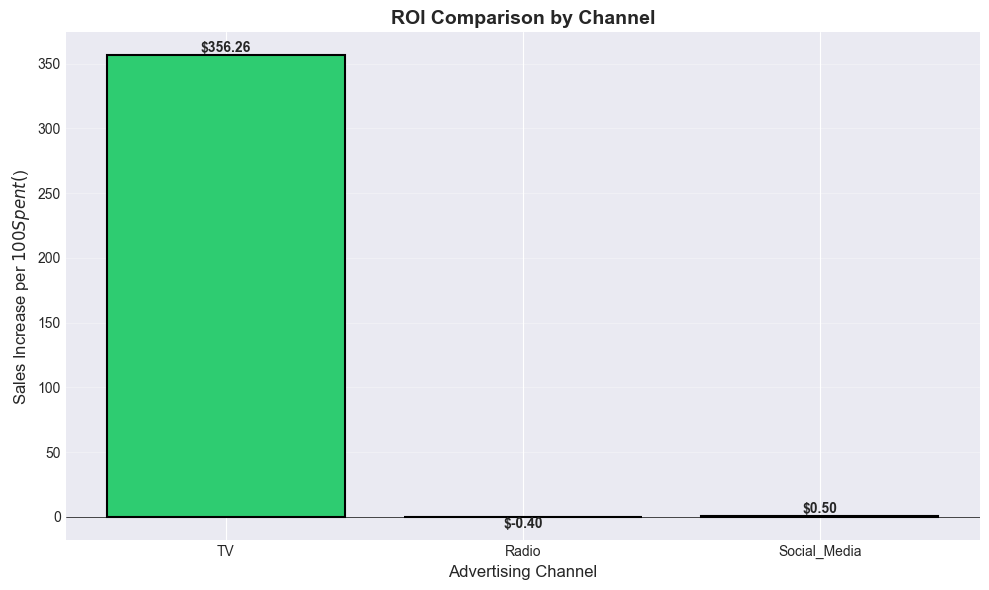

In [39]:
# Additional visualization for ROI comparison
plt.figure(figsize=(10, 6))
channels = list(roi_scores.keys())
roi_values = list(roi_scores.values())
colors = ['#2ecc71' if channel == best_channel else '#3498db' for channel in channels]

bars = plt.bar(channels, roi_values, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Sales Increase per $100 Spent ($)', fontsize=12)
plt.xlabel('Advertising Channel', fontsize=12)
plt.title('ROI Comparison by Channel', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Adding value labels on bars
for bar, value in zip(bars, roi_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${value:.2f}',
             ha='center', va='bottom' if value > 0 else 'top',
             fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()